<a href="https://colab.research.google.com/github/laasyavavila/PY191_lab/blob/main/July_28_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced CNN Techniques on MNIST

This notebook explains four concepts built on the same convolutional neural network:

1. **L1 and L2 regularization**
2. **Dropout techniques**
3. **SGD and Adam optimizers**
4. **Monte Carlo dropout for uncertainty quantification**

The convolutional architectures are fully provided. You are not asked to rebuild the CNN. The exercises focus on how training objectives, regularization methods, optimizers, and inference procedures change model behavior.

## Learning objectives

By the end of the notebook, you should be able to:

- add L1 and L2 penalties to a classification objective
- explain how L1 and L2 affect learned weights
- distinguish ordinary dropout from spatial dropout
- explain the difference between training-mode and evaluation-mode dropout
- compare SGD and Adam under controlled experimental conditions
- keep dropout active during inference for Monte Carlo sampling
- calculate predictive entropy as an uncertainty measure
- evaluate whether uncertainty is higher for mistakes and degraded inputs
- interpret selective prediction as an accuracy–coverage tradeoff

## Exercise format

- CNN definitions and routine dataset setup are provided in full.
- Short expressions use the format `variable = ...`.
- Training loops use staged `TODO` comments so that you can organize the operations yourself.
- Run the notebook from top to bottom because later sections reuse models and results from earlier sections.

# Shared Setup

The following cells prepare the dataset, define the CNN architectures, and provide utilities reused throughout all four modules.

## S1. Import libraries and select a device

The notebook uses PyTorch, torchvision, NumPy, Matplotlib, and scikit-learn.

`FAST_MODE` controls the default runtime:

- `True`: uses a smaller training subset and fewer epochs
- `False`: uses most of MNIST and longer experiments

The default is appropriate for a normal Colab lab. Students can switch it off for more stable comparisons.

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    Subset,
    random_split
)

from torchvision import (
    datasets,
    transforms
)

torch.manual_seed(7)
np.random.seed(7)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

FAST_MODE = True

if FAST_MODE:

    TRAIN_SIZE = 12000
    VALIDATION_SIZE = 3000

    REGULARIZATION_EPOCHS = 2
    DROPOUT_EPOCHS = 2
    OPTIMIZER_EPOCHS = 2

    MC_PASSES = 20
    MC_TEST_SIZE = 2000

else:

    TRAIN_SIZE = 54000
    VALIDATION_SIZE = 6000

    REGULARIZATION_EPOCHS = 4
    DROPOUT_EPOCHS = 4
    OPTIMIZER_EPOCHS = 4

    MC_PASSES = 50
    MC_TEST_SIZE = 10000

BATCH_SIZE = 128

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Fast mode:", FAST_MODE)

PyTorch version: 2.11.0+cpu
Device: cpu
Fast mode: True


## S2. Load MNIST and create data loaders

The same training, validation, and test sets are used throughout the notebook.

`make_train_loader(seed)` creates a newly shuffled training loader. Reusing the same seed across experimental conditions gives the models the same mini-batch order, making comparisons more controlled.

In [2]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

unused_size = (
    len(full_train_dataset)
    - TRAIN_SIZE
    - VALIDATION_SIZE
)

(
    train_dataset,
    validation_dataset,
    unused_dataset
) = random_split(
    full_train_dataset,
    lengths=[
        TRAIN_SIZE,
        VALIDATION_SIZE,
        unused_size
    ],
    generator=torch.Generator().manual_seed(7)
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

mc_test_dataset = Subset(
    test_dataset,
    range(MC_TEST_SIZE)
)

mc_test_loader = DataLoader(
    mc_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def make_train_loader(seed=7):

    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(
            seed
        )
    )


print("Training samples:", len(train_dataset))
print(
    "Validation samples:",
    len(validation_dataset)
)
print("Test samples:", len(test_dataset))
print(
    "MC-dropout test samples:",
    len(mc_test_dataset)
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.85MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.65MB/s]

Training samples: 12000
Validation samples: 3000
Test samples: 10000
MC-dropout test samples: 2000


## S3. Inspect several MNIST images

The images are grayscale tensors with shape:

```text
channels × height × width
```

MNIST therefore uses the shape `(1, 28, 28)` for each image.

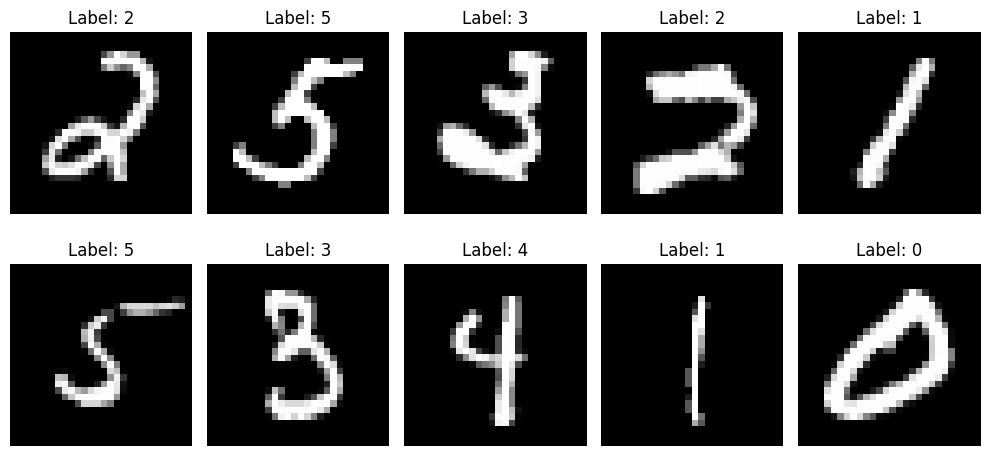

In [3]:
figure, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5)
)

for index, axis in enumerate(axes.flat):

    image, label = train_dataset[index]

    axis.imshow(
        image.squeeze(),
        cmap="gray"
    )

    axis.set_title(f"Label: {label}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## S4. Provided baseline CNN

This architecture is used for the L1/L2 and optimizer exercises.

```text
Input: 1 × 28 × 28

Conv2d: 1 → 16
ReLU
MaxPool2d

Conv2d: 16 → 32
ReLU
MaxPool2d

Flatten
Linear: 32 × 7 × 7 → 128
ReLU
Linear: 128 → 10
```

The CNN is fully provided. Students do not need to fill in any architecture code.

In [4]:
class BaseCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                32 * 7 * 7,
                128
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        features = self.features(x)
        logits = self.classifier(features)

        return logits

## S5. Dropout CNN

This architecture is used for both the dropout and Monte Carlo dropout modules.

It should include:

- `nn.Dropout2d` after convolutional blocks
- `nn.Dropout` after the hidden fully connected layer

A probability of zero disables the corresponding dropout operation without changing the parameterized layers.

In [8]:
class DropoutCNN(nn.Module):

    def __init__(
        self,
        convolution_dropout=0.0,
        classifier_dropout=0.0
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # TODO 1 Insert a convolutional dropout here
            nn.Dropout2d(
                p=convolution_dropout
            ),
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # TODO 2 Insert another convolutional dropout here
            nn.Dropout2d(
                p=convolution_dropout
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                32 * 7 * 7,
                128
            ),
            nn.ReLU(),
            # TODO 3 Insert an FC dropout here
            nn.Dropout(
                p=classifier_dropout
            ),
            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        features = self.features(x)
        logits = self.classifier(features)

        return logits

## S6. Verify the provided architectures

Both networks should produce one vector of ten logits per image.

In [9]:
sample_images, sample_labels = next(
    iter(make_train_loader(seed=7))
)

sample_images = sample_images.to(device)

base_probe = BaseCNN().to(device)

dropout_probe = DropoutCNN(
    convolution_dropout=0.25,
    classifier_dropout=0.50
).to(device)

with torch.no_grad():

    base_logits = base_probe(
        sample_images[:8]
    )

    dropout_logits = dropout_probe(
        sample_images[:8]
    )

print(
    "Base CNN output shape:",
    base_logits.shape
)

print(
    "Dropout CNN output shape:",
    dropout_logits.shape
)

Base CNN output shape: torch.Size([8, 10])
Dropout CNN output shape: torch.Size([8, 10])


## S7. Shared ordinary evaluation function

Validation and ordinary test evaluation use deterministic inference:

- `model.eval()` disables dropout
- `torch.no_grad()` disables gradient tracking
- no parameters are updated

In [10]:
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    average_loss = (
        running_loss / total
    )

    accuracy = correct / total

    return average_loss, accuracy

## S8. Shared standard training function

This completed function is used where the learning objective is not the basic training loop.

Specialized modules still ask you to implement their technique-specific training logic.

In [11]:
def train_standard_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    average_loss = (
        running_loss / total
    )

    accuracy = correct / total

    return average_loss, accuracy

## S9. Save controlled initial states

The experiments reload identical initial weights before comparing conditions.

In [12]:
torch.manual_seed(7)

base_initial_state = copy.deepcopy(
    BaseCNN().state_dict()
)

torch.manual_seed(7)

dropout_initial_state = copy.deepcopy(
    DropoutCNN(
        convolution_dropout=0.0,
        classifier_dropout=0.0
    ).state_dict()
)

print("Initial states saved.")

Initial states saved.


# Part I — L1 and L2 Regularization

Regularization changes the objective optimized during training.

Ordinary classification training minimizes:

$$L_{classification}$$

A regularized model minimizes:


$$L_{total}=L_{classification}+ \lambda R(\theta)$$

For L1 regularization:


$$R(\theta)=\sum_i |\theta_i|$$

For L2 regularization:

$$R(\theta)=\sum_i \theta_i^2$$

The coefficient $\lambda$ controls the penalty strength.

## R1. Implement the regularization penalty

Regularize trainable weight tensors while excluding one-dimensional bias tensors.

Return:

- zero for `"none"`
- the sum of absolute weight values for `"l1"`
- the sum of squared weight values for `"l2"`

### Hint

**Core methods:** `.abs()`, `.pow(2)`, and `.sum()`

In [14]:
def regularization_penalty(
    model,
    regularization_type
):

    weight_tensors = [
        param for name, param in model.named_parameters()
        if "weight" in name
    ]

    if regularization_type == "none":

        penalty = 0.0

    elif regularization_type == "l1":

        penalty = sum(torch.abs(w).sum() for w in weight_tensors)

    elif regularization_type == "l2":

        penalty = sum(torch.pow(w, 2).sum() for w in weight_tensors)

    else:

        raise ValueError(
            "regularization_type must be "
            "'none', 'l1', or 'l2'"
        )

    return penalty

## R2. Implement one regularized training epoch

For every batch:

1. move images and labels to the device
2. clear old gradients
3. calculate logits
4. calculate classification loss
5. calculate the regularization penalty
6. combine the two loss terms
7. backpropagate and update parameters
8. accumulate total loss and accuracy

The reported training loss is the total optimized loss.

In [20]:
def train_regularized_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    regularization_type,
    regularization_strength
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        # TODO 1: Move images and labels
        # to the selected device.
        images = images.to(device)
        labels = labels.to(device)

        # TODO 2: Clear gradients from
        # the previous batch.
        optimizer.zero_grad()

        # TODO 3: Calculate logits.
        logits = model(images)

        # TODO 4: Calculate the ordinary
        # classification loss.
        loss = criterion(
            logits,
            labels
        )

        # TODO 5: Calculate the selected
        # regularization penalty.
        penalty = regularization_penalty(
            model,
            regularization_type
        )

        # TODO 6: Combine classification
        # loss and the weighted penalty.
        total_loss = loss + regularization_strength * penalty

        # TODO 7: Backpropagate the total
        # loss and update parameters.
        total_loss.backward()
        optimizer.step()

        # TODO 8: Accumulate total loss,
        # correct predictions, and count.
        running_loss += total_loss.item() * images.size(0)

        _, predicted = torch.max(logits, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)


    average_loss = (
        running_loss / total
    )

    accuracy = correct / total

    return average_loss, accuracy

## R3. Run one regularization condition

Every condition receives:

- identical initial parameters
- the same mini-batch order
- the same optimizer and learning rate
- the same number of epochs

In [21]:
def run_regularization_experiment(
    regularization_type,
    regularization_strength,
    seed=19
):

    model = BaseCNN().to(device)

    model.load_state_dict(
        base_initial_state
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_loader = make_train_loader(
        seed
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": []
    }

    for epoch in range(
        REGULARIZATION_EPOCHS
    ):

        (
            train_loss,
            train_accuracy
        ) = train_regularized_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            regularization_type,
            regularization_strength
        )

        (
            validation_loss,
            validation_accuracy
        ) = evaluate_model(
            model,
            validation_loader,
            criterion,
            device
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["validation_loss"].append(
            validation_loss
        )

        history[
            "validation_accuracy"
        ].append(
            validation_accuracy
        )

        print(
            f"{regularization_type.upper():4s} | "
            f"Epoch {epoch + 1}/"
            f"{REGULARIZATION_EPOCHS} | "
            f"Train accuracy: "
            f"{train_accuracy:.3f} | "
            f"Validation accuracy: "
            f"{validation_accuracy:.3f}"
        )

    return model, history

In [22]:
train_loader = make_train_loader(19)

print("Number of batches:", len(train_loader))

for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

Number of batches: 94
torch.Size([128, 1, 28, 28]) torch.Size([128])


## R4. Train baseline, L1, and L2 models

The coefficients are intentionally small because the penalties sum over many parameters.

They are starting values, not universal defaults.

In [23]:
regularization_configurations = {
    "Baseline": ("none", 0.0),
    "L1": ("l1", 1e-6),
    "L2": ("l2", 1e-5)
}

regularization_models = {}
regularization_histories = {}

for name, (
    regularization_type,
    regularization_strength
) in regularization_configurations.items():

    print("\nRunning:", name)

    model, history = (
        run_regularization_experiment(
            regularization_type,
            regularization_strength
        )
    )

    regularization_models[name] = model

    regularization_histories[
        name
    ] = history


Running: Baseline
NONE | Epoch 1/2 | Train accuracy: 0.727 | Validation accuracy: 0.912
NONE | Epoch 2/2 | Train accuracy: 0.928 | Validation accuracy: 0.947

Running: L1
L1   | Epoch 1/2 | Train accuracy: 0.727 | Validation accuracy: 0.911
L1   | Epoch 2/2 | Train accuracy: 0.930 | Validation accuracy: 0.947

Running: L2
L2   | Epoch 1/2 | Train accuracy: 0.727 | Validation accuracy: 0.913
L2   | Epoch 2/2 | Train accuracy: 0.929 | Validation accuracy: 0.947


## R5. Compare validation accuracy

Plot one validation-accuracy curve for each condition.

### Hint

Loop through `regularization_histories.items()`.

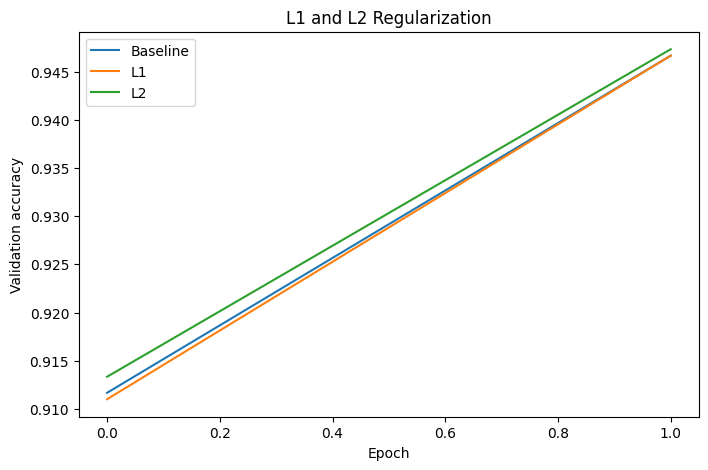

In [24]:
plt.figure(figsize=(8, 5))

for name, history in (
    regularization_histories.items()
):

    validation_line = plt.plot(
        history["validation_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(
    "L1 and L2 Regularization"
)
plt.legend()
plt.show()

## R6. Evaluate the regularized models

Test loss is ordinary classification loss. The penalty influences training but is not part of predictive test performance.

In [25]:
criterion = nn.CrossEntropyLoss()

regularization_test_results = {}

for name, model in (
    regularization_models.items()
):

    test_loss, test_accuracy = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            device
        )
    )

    regularization_test_results[
        name
    ] = {
        "loss": test_loss,
        "accuracy": test_accuracy
    }

    print(
        f"{name:8s} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: "
        f"{test_accuracy:.3f}"
    )

Baseline | Test loss: 0.1861 | Test accuracy: 0.945
L1       | Test loss: 0.1815 | Test accuracy: 0.948
L2       | Test loss: 0.1824 | Test accuracy: 0.946


## R7. Inspect learned weight statistics

Calculate:

- mean absolute weight magnitude
- fraction of absolute weight values below `0.001`

L1 often produces more values close to zero, although ordinary gradient training does not guarantee exact zeros.

In [26]:
def weight_statistics(model):

    all_weights = torch.cat(
        [
            param.detach().view(-1)
            for name, param in model.named_parameters()
            if "weight" in name
        ]
    )

    mean_absolute_weight = all_weights.abs().mean().item()

    near_zero_fraction = (
        (all_weights.abs() < 1e-3)
        .float()
        .mean()
        .item()
    )

    return (
        mean_absolute_weight,
        near_zero_fraction
    )


for name, model in (
    regularization_models.items()
):

    (
        mean_weight,
        near_zero
    ) = weight_statistics(model)

    print(
        f"{name:8s} | "
        f"Mean |weight|: "
        f"{mean_weight:.5f} | "
        f"Near-zero fraction: "
        f"{near_zero:.3f}"
    )

Baseline | Mean |weight|: 0.01896 | Near-zero fraction: 0.034
L1       | Mean |weight|: 0.01473 | Near-zero fraction: 0.261
L2       | Mean |weight|: 0.01590 | Near-zero fraction: 0.140


# Part II — Dropout Techniques

Dropout randomly removes activations during training.

This notebook uses:

- `Dropout2d` to remove entire convolutional feature channels
- `Dropout` to remove individual fully connected activations

During ordinary evaluation, dropout is disabled.

## D1. Observe dropout behavior

The CNN is already provided and you should have implemented the dropout modules.

Run the same batch through a dropout model twice in training mode and twice in evaluation mode.

Calculate the mean absolute difference between each pair of outputs.

### Hint

Training-mode outputs should differ because new masks are sampled. Evaluation-mode outputs should match.

In [28]:
probe_model = DropoutCNN(
    convolution_dropout=0.25,
    classifier_dropout=0.50
).to(device)

probe_images, probe_labels = next(
    iter(make_train_loader(seed=7))
)

probe_images = (
    probe_images[:16].to(device)
)

probe_model.train()

with torch.no_grad():

    train_logits_a = probe_model(
        probe_images
    )

    train_logits_b = probe_model(
        probe_images
    )

training_mode_difference = (
    torch.abs(train_logits_a - train_logits_b).mean().item()
)

probe_model.eval()

with torch.no_grad():

    evaluation_logits_a = probe_model(
        probe_images
    )

    evaluation_logits_b = probe_model(
        probe_images
    )

evaluation_mode_difference = (
    torch.abs(evaluation_logits_a - evaluation_logits_b).mean().item()
)

print(
    "Training-mode difference:",
    training_mode_difference
)

print(
    "Evaluation-mode difference:",
    evaluation_mode_difference
)

Training-mode difference: 0.04802621528506279
Evaluation-mode difference: 0.0


## D2. Run one dropout experiment

This function uses the completed standard training loop.

The only changing factors are the two dropout probabilities.

In [29]:
def run_dropout_experiment(
    convolution_dropout,
    classifier_dropout,
    seed=23
):

    model = DropoutCNN(
        convolution_dropout=(
            convolution_dropout
        ),
        classifier_dropout=(
            classifier_dropout
        )
    ).to(device)

    model.load_state_dict(
        dropout_initial_state
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_loader = make_train_loader(
        seed
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": []
    }

    for epoch in range(
        DROPOUT_EPOCHS
    ):

        (
            train_loss,
            train_accuracy
        ) = train_standard_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        (
            validation_loss,
            validation_accuracy
        ) = evaluate_model(
            model,
            validation_loader,
            criterion,
            device
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["validation_loss"].append(
            validation_loss
        )

        history[
            "validation_accuracy"
        ].append(
            validation_accuracy
        )

        print(
            f"Epoch {epoch + 1}/"
            f"{DROPOUT_EPOCHS} | "
            f"Train accuracy: "
            f"{train_accuracy:.3f} | "
            f"Validation accuracy: "
            f"{validation_accuracy:.3f}"
        )

    return model, history

## D3. Compare no dropout and moderate dropout

Both conditions use the same parameter initialization and mini-batch order.

In [30]:
dropout_configurations = {
    "No dropout": (0.0, 0.0),
    "Dropout": (0.25, 0.50)
}

dropout_models = {}
dropout_histories = {}

for name, (
    convolution_dropout,
    classifier_dropout
) in dropout_configurations.items():

    print("\nRunning:", name)

    model, history = (
        run_dropout_experiment(
            convolution_dropout,
            classifier_dropout
        )
    )

    dropout_models[name] = model
    dropout_histories[name] = history


Running: No dropout
Epoch 1/2 | Train accuracy: 0.757 | Validation accuracy: 0.919
Epoch 2/2 | Train accuracy: 0.927 | Validation accuracy: 0.944

Running: Dropout
Epoch 1/2 | Train accuracy: 0.623 | Validation accuracy: 0.909
Epoch 2/2 | Train accuracy: 0.867 | Validation accuracy: 0.939


## D4. Plot training and validation accuracy

Create one training-accuracy figure and one validation-accuracy figure.

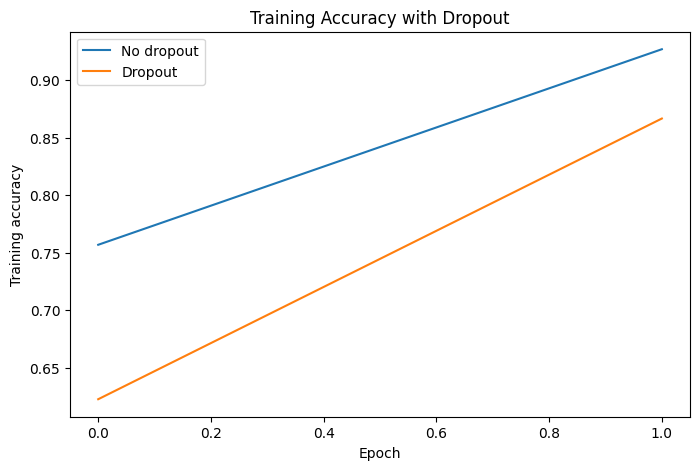

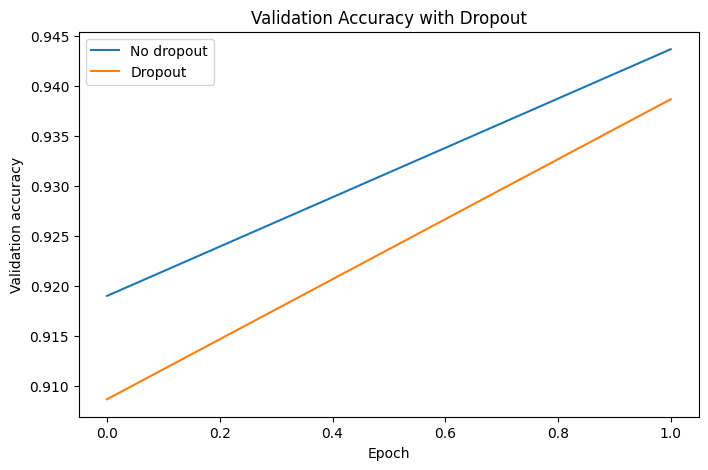

In [31]:
plt.figure(figsize=(8, 5))

for name, history in (
    dropout_histories.items()
):

    training_line = plt.plot(
        history["train_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training accuracy")
plt.title(
    "Training Accuracy with Dropout"
)
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

for name, history in (
    dropout_histories.items()
):

    validation_line = plt.plot(
        history["validation_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(
    "Validation Accuracy with Dropout"
)
plt.legend()
plt.show()

## D5. Compare generalization gaps and test accuracy

The final generalization gap is:

```text
training accuracy − validation accuracy
```

A smaller gap is useful only when the validation performance itself remains strong.

In [32]:
criterion = nn.CrossEntropyLoss()

dropout_test_results = {}

for name, model in (
    dropout_models.items()
):

    history = dropout_histories[name]

    generalization_gap = (
        history["train_accuracy"][-1]
        - history["validation_accuracy"][-1]
    )

    test_loss, test_accuracy = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            device
        )
    )

    dropout_test_results[name] = {
        "gap": generalization_gap,
        "loss": test_loss,
        "accuracy": test_accuracy
    }

    print(
        f"{name:10s} | "
        f"Gap: {generalization_gap:.3f} | "
        f"Test accuracy: "
        f"{test_accuracy:.3f}"
    )

No dropout | Gap: -0.017 | Test accuracy: 0.947
Dropout    | Gap: -0.072 | Test accuracy: 0.938


## D6. Strong-dropout extension

Train one additional condition using:

- convolution dropout: `0.50`
- classifier dropout: `0.70`

Compare its results with moderate dropout.

### Question

Does stronger dropout improve generalization, or does it cause underfitting?

In [33]:
strong_dropout_model, (
    strong_dropout_history
) = run_dropout_experiment(
    convolution_dropout=0.50,
    classifier_dropout=0.70
)

Epoch 1/2 | Train accuracy: 0.455 | Validation accuracy: 0.871
Epoch 2/2 | Train accuracy: 0.768 | Validation accuracy: 0.919


# Part III — SGD and Adam Optimizers

An optimizer converts gradients into parameter updates.

Plain stochastic gradient descent uses the current gradient and one learning-rate rule.

Adam maintains adaptive moving averages of gradients and squared gradients, allowing different parameter dimensions to receive differently scaled updates.

## O1. Create an optimizer factory

Use:

- SGD with learning rate `0.05`
- Adam with learning rate `0.001`

The numerical learning rates differ because the optimizers process gradient information differently.

In [34]:
def make_optimizer(
    optimizer_name,
    model
):

    if optimizer_name == "sgd":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.05
        )

    elif optimizer_name == "adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.001
        )

    else:

        raise ValueError(
            "optimizer_name must be "
            "'sgd' or 'adam'"
        )

    return optimizer

## O2. Implement one epoch with batch-loss tracking

In addition to epoch loss and accuracy, collect the loss from every mini-batch.

Batch-level loss reveals early optimization behavior more clearly than one value per epoch.

In [35]:
from torch.nn.modules import loss
def train_epoch_with_batch_losses(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    batch_losses = []

    for images, labels in loader:

        # TODO 1: Move the batch
        # to the selected device.
        images = images.to(device)
        labels = labels.to(device)

        # TODO 2: Clear gradients.
        optimizer.zero_grad()

        # TODO 3: Calculate logits
        # and classification loss.
        logits = model(images)
        loss = criterion(logits, labels)

        # TODO 4: Backpropagate
        # and update parameters.
        loss.backward()
        optimizer.step()

        # TODO 5: Store the current
        # mini-batch loss.
        batch_losses.append(loss.item())

        # TODO 6: Accumulate epoch
        # loss, correct predictions,
        # and count.
        running_loss += loss.item()
        predictions = torch.argmax(
            logits,
            dim=1
        )
        correct += (
            predictions == labels
        ).sum().item()
        total += labels.size(0)

    average_loss = (
        running_loss / total
    )

    accuracy = correct / total

    return (
        average_loss,
        accuracy,
        batch_losses
    )

## O3. Run one optimizer condition

Both optimizers receive:

- the same CNN architecture
- identical initial parameters
- the same mini-batch order
- the same number of epochs

In [36]:
def run_optimizer_experiment(
    optimizer_name,
    seed=31
):

    model = BaseCNN().to(device)

    model.load_state_dict(
        base_initial_state
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = make_optimizer(
        optimizer_name,
        model
    )

    train_loader = make_train_loader(
        seed
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "batch_losses": []
    }

    for epoch in range(
        OPTIMIZER_EPOCHS
    ):

        (
            train_loss,
            train_accuracy,
            batch_losses
        ) = train_epoch_with_batch_losses(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        (
            validation_loss,
            validation_accuracy
        ) = evaluate_model(
            model,
            validation_loader,
            criterion,
            device
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["validation_loss"].append(
            validation_loss
        )

        history[
            "validation_accuracy"
        ].append(
            validation_accuracy
        )

        history["batch_losses"].extend(
            batch_losses
        )

        print(
            f"{optimizer_name.upper():4s} | "
            f"Epoch {epoch + 1}/"
            f"{OPTIMIZER_EPOCHS} | "
            f"Train loss: "
            f"{train_loss:.4f} | "
            f"Validation accuracy: "
            f"{validation_accuracy:.3f}"
        )

    return model, history

## O4. Train SGD and Adam models

In [37]:
optimizer_models = {}
optimizer_histories = {}

for optimizer_name in [
    "sgd",
    "adam"
]:

    print(
        "\nRunning:",
        optimizer_name.upper()
    )

    model, history = (
        run_optimizer_experiment(
            optimizer_name
        )
    )

    optimizer_models[
        optimizer_name
    ] = model

    optimizer_histories[
        optimizer_name
    ] = history


Running: SGD
SGD  | Epoch 1/2 | Train loss: 0.0152 | Validation accuracy: 0.425
SGD  | Epoch 2/2 | Train loss: 0.0052 | Validation accuracy: 0.832

Running: ADAM
ADAM | Epoch 1/2 | Train loss: 0.0066 | Validation accuracy: 0.907
ADAM | Epoch 2/2 | Train loss: 0.0019 | Validation accuracy: 0.950


## O5. Compare early mini-batch losses

Plot the first 100 parameter updates for each optimizer.

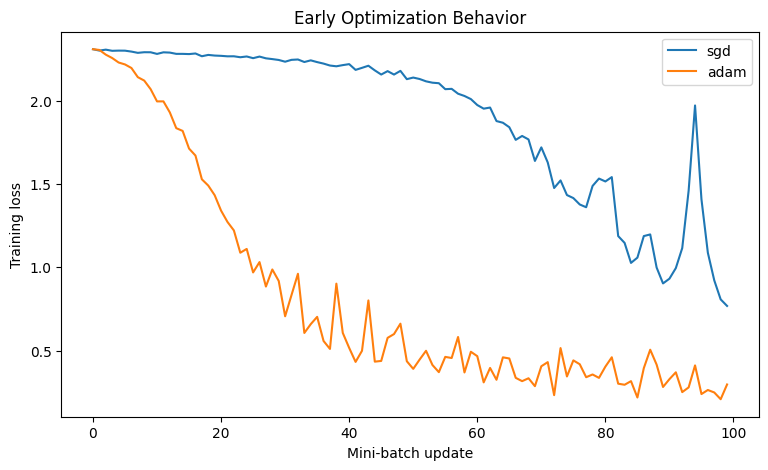

In [38]:
plt.figure(figsize=(9, 5))

for optimizer_name, history in (
    optimizer_histories.items()
):

    batch_loss_line = plt.plot(
        history["batch_losses"][:100],
        label=optimizer_name
    )

plt.xlabel("Mini-batch update")
plt.ylabel("Training loss")
plt.title(
    "Early Optimization Behavior"
)
plt.legend()
plt.show()

## O6. Compare validation accuracy

Fast early loss reduction does not guarantee better generalization.

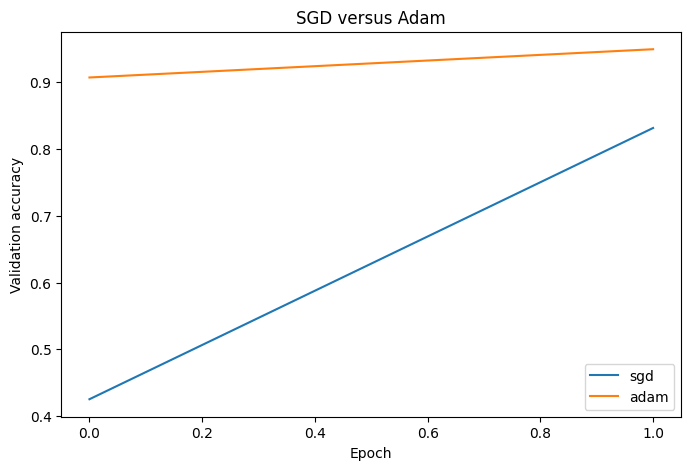

In [39]:
plt.figure(figsize=(8, 5))

for optimizer_name, history in (
    optimizer_histories.items()
):

    validation_line = plt.plot(
        history["validation_accuracy"],
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("SGD versus Adam")
plt.legend()
plt.show()

## O7. Evaluate both optimizers on the test set

In [40]:
criterion = nn.CrossEntropyLoss()

optimizer_test_results = {}

for optimizer_name, model in (
    optimizer_models.items()
):

    test_loss, test_accuracy = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            device
        )
    )

    optimizer_test_results[
        optimizer_name
    ] = {
        "loss": test_loss,
        "accuracy": test_accuracy
    }

    print(
        f"{optimizer_name.upper():4s} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: "
        f"{test_accuracy:.3f}"
    )

SGD  | Test loss: 0.5271 | Test accuracy: 0.835
ADAM | Test loss: 0.1686 | Test accuracy: 0.950


## O8. Momentum extension

Create an SGD optimizer using:

- learning rate `0.05`
- momentum `0.9`

### Question

How would you incorporate this third condition into the controlled experiment?

In [41]:
momentum_model = BaseCNN().to(device)

momentum_model.load_state_dict(
    base_initial_state
)

momentum_optimizer = torch.optim.SGD(
    momentum_model.parameters(),
    lr=0.05,
    momentum=0.9
)

# Part IV — Monte Carlo Dropout for Uncertainty Quantification

A standard classifier returns one deterministic prediction.

Monte Carlo dropout instead:

1. keeps dropout active during inference
2. runs the same input through many random subnetworks
3. converts every output to class probabilities
4. examines the average distribution and variation

This module reuses the trained moderate-dropout model from Part II. The CNN architecture is not rebuilt.

## M1. Reuse the trained dropout model

A deep copy is used so that the uncertainty experiments do not change the stored Part II model.

In [42]:
mc_model = copy.deepcopy(
    dropout_models["Dropout"]
).to(device)

print(mc_model)

DropoutCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## M2. Activate only dropout modules during inference

Calling `model.train()` would activate dropout, but it would also activate any other training-sensitive layers.

A safer procedure is:

1. call `model.eval()` for the entire network
2. find dropout modules
3. switch only those modules back to training mode

Complete the expression inside the conditional.

In [43]:
def enable_mc_dropout(model):

    model.eval()

    for module in model.modules():

        if isinstance(
            module,
            (
                nn.Dropout,
                nn.Dropout2d
            )
        ):

            module.train()

## M3. Implement Monte Carlo prediction for one batch

For the same image batch:

1. enable dropout during inference
2. perform `num_samples` stochastic forward passes
3. convert logits to probabilities
4. stack all probability tensors
5. average probabilities across samples
6. calculate predictive entropy

Predictive entropy is:

$$H(p)=-\sum_c p_c \log(p_c)$$

The stacked probability tensor should have shape:

```text
MC samples × batch size × classes
```

In [48]:
def mc_dropout_batch(
    model,
    images,
    num_samples
):

    enable_mc_dropout(model)

    probability_samples = []

    with torch.no_grad():

        for sample_index in range(
            num_samples
        ):

            # TODO 1: Calculate logits
            # with dropout active.
            logits = model(images)

            # TODO 2: Convert logits
            # to class probabilities.
            probabilities = torch.softmax(
                logits,
                dim=1
            )

            # TODO 3: Append the current
            # probability tensor.
            probability_samples.append(
                probabilities
            )


    stacked_probabilities = torch.stack(
        probability_samples,
        dim=0
    )

    mean_probabilities = (
        stacked_probabilities.mean(dim=0)
    )

    predictive_entropy = -(
        mean_probabilities *
        torch.log(mean_probabilities + 1e-12)
        ).sum(dim=1)

    return (
        mean_probabilities,
        predictive_entropy,
        stacked_probabilities
    )

## M4. Collect Monte Carlo results across the test subset

The helper function returns:

- predicted labels
- true labels
- predictive entropies
- mean class probabilities

The smaller MC test subset keeps repeated inference practical in Colab.

In [50]:
def collect_mc_results(
    model,
    loader,
    device,
    num_samples
):

    prediction_batches = []
    label_batches = []
    entropy_batches = []
    probability_batches = []

    for images, labels in loader:

        images = images.to(device)

        (
            mean_probabilities,
            predictive_entropy,
            probability_samples
        ) = mc_dropout_batch(
            model,
            images,
            num_samples
        )

        predictions = torch.argmax(
            mean_probabilities,
            dim=1
        )

        prediction_batches.append(
            predictions.cpu()
        )

        label_batches.append(labels)

        entropy_batches.append(
            predictive_entropy.cpu()
        )

        probability_batches.append(
            mean_probabilities.cpu()
        )

    all_predictions = torch.cat(
        prediction_batches
    )

    all_labels = torch.cat(
        label_batches
    )

    all_entropies = torch.cat(
        entropy_batches
    )

    all_mean_probabilities = (
        torch.cat(
            probability_batches
        )
    )

    return (
        all_predictions,
        all_labels,
        all_entropies,
        all_mean_probabilities
    )


(
    mc_predictions,
    mc_labels,
    mc_entropies,
    mc_mean_probabilities
) = collect_mc_results(
    mc_model,
    mc_test_loader,
    device,
    MC_PASSES
)

mc_accuracy = (
    (mc_predictions == mc_labels)
    .float()
    .mean()
    .item()
)

print(
    f"MC-dropout accuracy: "
    f"{mc_accuracy:.3f}"
)

MC-dropout accuracy: 0.916


## M5. Compare uncertainty for correct and incorrect predictions

A useful uncertainty measure should generally be larger for mistakes.

Calculate:

- a mask for correct predictions
- a mask for incorrect predictions
- mean entropy for each group

In [51]:
correct_mask = (
    mc_predictions == mc_labels
)
incorrect_mask = (
    mc_predictions != mc_labels
)

correct_entropy = (
    mc_entropies[
        correct_mask
    ].mean().item()
)

incorrect_entropy = (
    mc_entropies[
        incorrect_mask
    ].mean().item()
)

print(
    "Mean entropy for correct "
    "predictions:",
    correct_entropy
)

print(
    "Mean entropy for incorrect "
    "predictions:",
    incorrect_entropy
)

Mean entropy for correct predictions: 0.566070020198822
Mean entropy for incorrect predictions: 1.2671185731887817


## M6. Visualize the most uncertain test images

Sort the MC test subset from highest entropy to lowest entropy.

The plotting code displays the twelve most uncertain images.

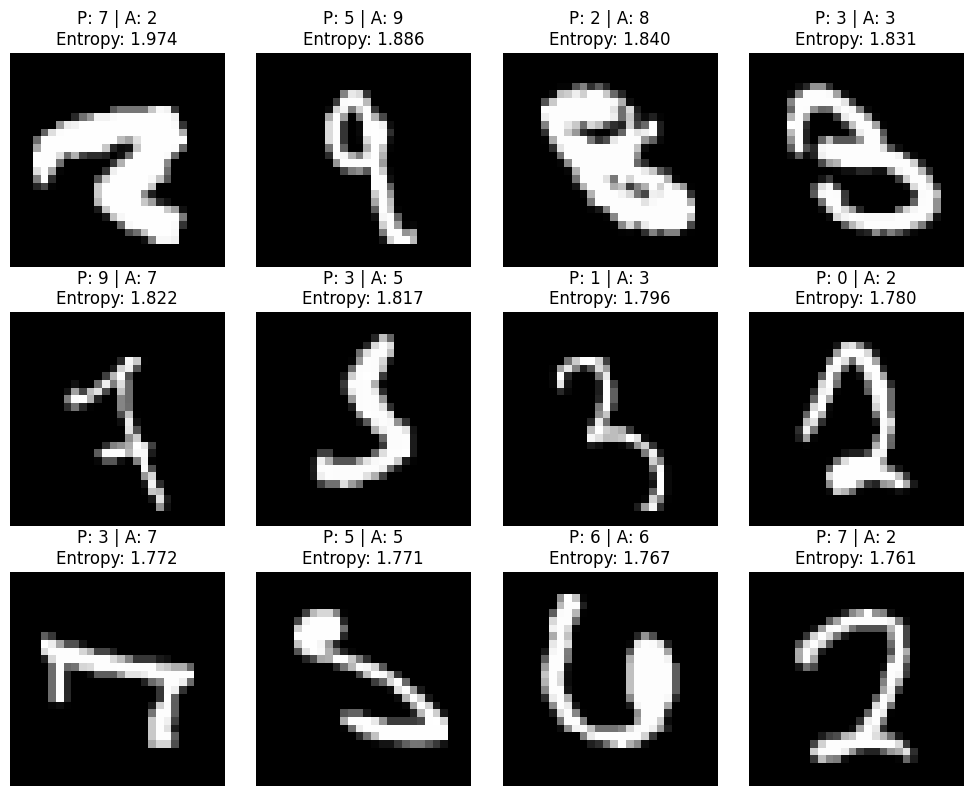

In [52]:
uncertain_order = torch.argsort(
    mc_entropies,
    descending=True
)

figure, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

for plot_index, axis in enumerate(
    axes.flat
):

    subset_index = uncertain_order[
        plot_index
    ].item()

    image, actual_label = (
        mc_test_dataset[
            subset_index
        ]
    )

    predicted_label = (
        mc_predictions[
            subset_index
        ].item()
    )

    entropy = mc_entropies[
        subset_index
    ].item()

    axis.imshow(
        image.squeeze(),
        cmap="gray"
    )

    axis.set_title(
        f"P: {predicted_label} | "
        f"A: {actual_label}\n"
        f"Entropy: {entropy:.3f}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

## M7. Compare clean and noisy inputs

Add Gaussian noise to one test batch, clamp pixel values to `[0, 1]`, and compare mean predictive entropy.

A useful uncertainty method should often assign greater uncertainty to degraded images, although this is not guaranteed for every individual example.

In [53]:
clean_images, clean_labels = next(
    iter(mc_test_loader)
)

clean_images = clean_images.to(device)

noisy_images = clean_images + 0.3 * torch.randn_like(clean_images)

noisy_images = torch.clamp(
    noisy_images,
    0.0,
    1.0
)

(
    clean_mean_probabilities,
    clean_entropies,
    clean_probability_samples
) = mc_dropout_batch(
    mc_model,
    clean_images,
    MC_PASSES
)

(
    noisy_mean_probabilities,
    noisy_entropies,
    noisy_probability_samples
) = mc_dropout_batch(
    mc_model,
    noisy_images,
    MC_PASSES
)

print(
    "Mean clean entropy:",
    clean_entropies.mean().item()
)

print(
    "Mean noisy entropy:",
    noisy_entropies.mean().item()
)

Mean clean entropy: 0.5628856420516968
Mean noisy entropy: 1.0093278884887695


## M8. Selective prediction

An uncertainty-aware system can refuse to predict on the most uncertain examples.

For each coverage level:

1. retain the requested fraction of the most certain examples
2. calculate accuracy only on the retained subset

If the entropy ranking is useful, accuracy should generally increase as coverage decreases.

In [55]:
certainty_order = torch.argsort(
    mc_entropies
)

coverage_levels = [
    0.25,
    0.50,
    0.75,
    1.00
]

selective_accuracies = []

for coverage in coverage_levels:

    retained_count = int(
        coverage
        * len(mc_labels)
    )

    retained_indexes = (
        certainty_order[
            :retained_count
        ]
    )

    retained_accuracy = (
        (
            mc_predictions[
                retained_indexes
            ]
            == mc_labels[
                retained_indexes
            ]
        )
        .float()
        .mean()
        .item()
    )

    selective_accuracies.append(
        retained_accuracy
    )

    print(
        f"Coverage: {coverage:.0%} | "
        f"Accuracy: "
        f"{retained_accuracy:.3f}"
    )

Coverage: 25% | Accuracy: 0.998
Coverage: 50% | Accuracy: 0.998
Coverage: 75% | Accuracy: 0.986
Coverage: 100% | Accuracy: 0.916


## M9. Plot accuracy against coverage

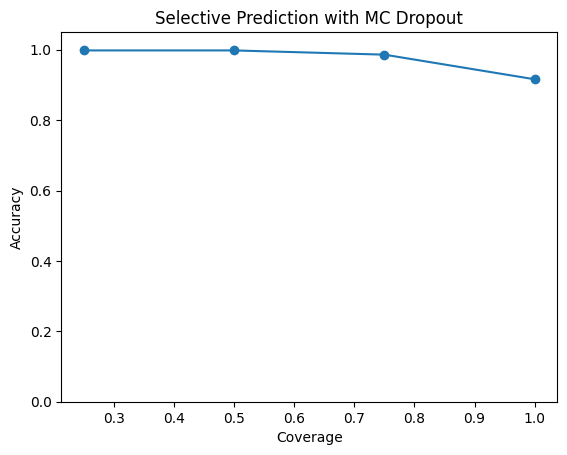

In [56]:
coverage_line = plt.plot(
    coverage_levels,
    selective_accuracies,
    marker="o"
)

plt.xlabel("Coverage")
plt.ylabel("Accuracy")
plt.title(
    "Selective Prediction "
    "with MC Dropout"
)
plt.ylim(0.0, 1.05)
plt.show()

## M10. Important limitations

Monte Carlo dropout provides an approximate uncertainty signal, not a guarantee that every mistake or unfamiliar input will receive high uncertainty.

Its behavior depends on:

- dropout placement and probabilities
- training data coverage
- model calibration
- the number of Monte Carlo samples
- how deployment inputs differ from training data

Uncertainty quality should be validated separately from classification accuracy.